# English POS Tagger with NLTK

## 1. Setup

In [17]:
import time
import matplotlib.pyplot as plt
from nltk.tag import DefaultTagger, UnigramTagger, BigramTagger, TrigramTagger
from nltk.tag import hmm

def run_pos_experiment(train_sents, test_sents, dataset_name, default_tag='NN'):
    """
    Train Default, Unigram, Bigram, Trigram, HMM taggers on a dataset
    and evaluate them on a test set.

    train_sents, test_sents: list of list of (word, tag)
    dataset_name: for printing / plot title
    default_tag: e.g. 'NN' for Brown, 'NOUN' for UD EWT
    """
    print(f"\n=== Dataset: {dataset_name} ===")
    print(f"Train sentences: {len(train_sents)}")
    print(f"Test sentences : {len(test_sents)}")

    # ----- 1. Train taggers -----
    default_tagger = DefaultTagger(default_tag)

    start = time.time()
    unigram_tagger = UnigramTagger(train_sents, backoff=default_tagger)
    print(f"UnigramTagger trained in {time.time() - start:.2f}s")

    start = time.time()
    bigram_tagger = BigramTagger(train_sents, backoff=unigram_tagger)
    print(f"BigramTagger trained in {time.time() - start:.2f}s")

    start = time.time()
    trigram_tagger = TrigramTagger(train_sents, backoff=bigram_tagger)
    print(f"TrigramTagger trained in {time.time() - start:.2f}s")

    start = time.time()
    trainer = hmm.HiddenMarkovModelTrainer()
    hmm_tagger = trainer.train_supervised(train_sents)
    print(f"HMM Tagger trained in {time.time() - start:.2f}s")

    # ----- 2. Evaluate -----
    tagger_names = ["Default", "Unigram", "Bigram", "Trigram", "HMM"]

    default_acc = default_tagger.evaluate(test_sents)
    unigram_acc = unigram_tagger.evaluate(test_sents)
    bigram_acc  = bigram_tagger.evaluate(test_sents)
    trigram_acc = trigram_tagger.evaluate(test_sents)
    hmm_acc     = hmm_tagger.evaluate(test_sents)

    accuracies = [default_acc, unigram_acc, bigram_acc, trigram_acc, hmm_acc]

    print("\nAccuracies:")
    for name, acc in zip(tagger_names, accuracies):
        print(f"- {name}: {acc:.4f} ({acc*100:.2f}%)")

    # ----- 3. Plot -----
    plt.figure(figsize=(8, 4))
    bars = plt.bar(tagger_names, [a * 100 for a in accuracies])
    plt.ylabel("Accuracy (%)")
    plt.ylim(0, 100)
    plt.title(f"POS Tagger Accuracy on {dataset_name} Test Set")

    for bar, acc in zip(bars, accuracies):
        h = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, h + 1,
                 f"{acc*100:.1f}%", ha='center', va='bottom')

    plt.tight_layout()
    plt.show()

    return {
        "dataset": dataset_name,
        "tagger_names": tagger_names,
        "accuracies": accuracies,
        "models": {
            "default": default_tagger,
            "unigram": unigram_tagger,
            "bigram": bigram_tagger,
            "trigram": trigram_tagger,
            "hmm": hmm_tagger,
        },
    }

## 2. Dataset 1: Brown Corpus (news)

In [18]:
from nltk.corpus import brown
import nltk

nltk.download('brown')

brown_sents = brown.tagged_sents(categories='news')

train_size = int(0.8 * len(brown_sents))
brown_train = brown_sents[:train_size]
brown_test  = brown_sents[train_size:]

print("Brown 'news' sentences:", len(brown_sents))
print("Train:", len(brown_train), "Test:", len(brown_test))


Brown 'news' sentences: 4623
Train: 3698 Test: 925


[nltk_data] Downloading package brown to /root/nltk_data...
[nltk_data]   Package brown is already up-to-date!



=== Dataset: Brown 'news' ===
Train sentences: 3698
Test sentences : 925
UnigramTagger trained in 0.21s
BigramTagger trained in 0.26s
TrigramTagger trained in 0.39s
HMM Tagger trained in 0.14s


<ipython-input-17-3025833c3569>:42: DeprecationWarning: 
  Function evaluate() has been deprecated.  Use accuracy(gold)
  instead.
  default_acc = default_tagger.evaluate(test_sents)
<ipython-input-17-3025833c3569>:43: DeprecationWarning: 
  Function evaluate() has been deprecated.  Use accuracy(gold)
  instead.
  unigram_acc = unigram_tagger.evaluate(test_sents)
<ipython-input-17-3025833c3569>:44: DeprecationWarning: 
  Function evaluate() has been deprecated.  Use accuracy(gold)
  instead.
  bigram_acc  = bigram_tagger.evaluate(test_sents)
<ipython-input-17-3025833c3569>:45: DeprecationWarning: 
  Function evaluate() has been deprecated.  Use accuracy(gold)
  instead.
  trigram_acc = trigram_tagger.evaluate(test_sents)
<ipython-input-17-3025833c3569>:46: DeprecationWarning: 
  Function evaluate() has been deprecated.  Use accuracy(gold)
  instead.
  hmm_acc     = hmm_tagger.evaluate(test_sents)



Accuracies:
- Default: 0.1210 (12.10%)
- Unigram: 0.8267 (82.67%)
- Bigram: 0.8361 (83.61%)
- Trigram: 0.8344 (83.44%)
- HMM: 0.2896 (28.96%)


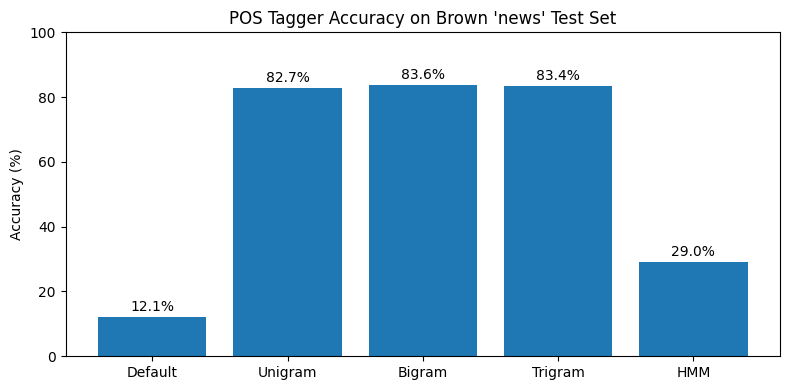

In [19]:
results_brown = run_pos_experiment(
    train_sents=brown_train,
    test_sents=brown_test,
    dataset_name="Brown 'news'",
    default_tag='NN'   # Brown tags use NN, VB, etc.
)

## 3. Dataset 2: UD English EWT

In [20]:
import os

def load_conllu(path):
    sentences = []
    sent = []
    with open(path, encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                if sent:
                    sentences.append(sent)
                    sent = []
                continue
            if line.startswith("#"):
                continue
            cols = line.split("\t")
            if len(cols) != 10:
                continue
            token_id = cols[0]
            if "-" in token_id or "." in token_id:  # skip multi-word / empty nodes
                continue
            word = cols[1]   # FORM
            upos = cols[3]   # UPOS
            sent.append((word, upos))
    if sent:
        sentences.append(sent)
    return sentences


In [21]:
ud_base = "/data/ud_english_ewt"  # adjust to your folder

train_path = os.path.join(ud_base, "en_ewt-ud-train.conllu")
dev_path   = os.path.join(ud_base, "en_ewt-ud-dev.conllu")
test_path  = os.path.join(ud_base, "en_ewt-ud-test.conllu")

ud_train_sents = load_conllu(train_path)
ud_dev_sents   = load_conllu(dev_path)
ud_test_sents  = load_conllu(test_path)

print("UD English EWT:")
print(" train:", len(ud_train_sents))
print(" dev  :", len(ud_dev_sents))
print(" test :", len(ud_test_sents))


UD English EWT:
 train: 12544
 dev  : 2001
 test : 2077



=== Dataset: UD English EWT ===
Train sentences: 14545
Test sentences : 2077
UnigramTagger trained in 0.32s
BigramTagger trained in 0.51s
TrigramTagger trained in 0.67s
HMM Tagger trained in 0.16s


<ipython-input-17-3025833c3569>:42: DeprecationWarning: 
  Function evaluate() has been deprecated.  Use accuracy(gold)
  instead.
  default_acc = default_tagger.evaluate(test_sents)
<ipython-input-17-3025833c3569>:43: DeprecationWarning: 
  Function evaluate() has been deprecated.  Use accuracy(gold)
  instead.
  unigram_acc = unigram_tagger.evaluate(test_sents)
<ipython-input-17-3025833c3569>:44: DeprecationWarning: 
  Function evaluate() has been deprecated.  Use accuracy(gold)
  instead.
  bigram_acc  = bigram_tagger.evaluate(test_sents)
<ipython-input-17-3025833c3569>:45: DeprecationWarning: 
  Function evaluate() has been deprecated.  Use accuracy(gold)
  instead.
  trigram_acc = trigram_tagger.evaluate(test_sents)
<ipython-input-17-3025833c3569>:46: DeprecationWarning: 
  Function evaluate() has been deprecated.  Use accuracy(gold)
  instead.
  hmm_acc     = hmm_tagger.evaluate(test_sents)



Accuracies:
- Default: 0.1643 (16.43%)
- Unigram: 0.8669 (86.69%)
- Bigram: 0.8783 (87.83%)
- Trigram: 0.8774 (87.74%)
- HMM: 0.5909 (59.09%)


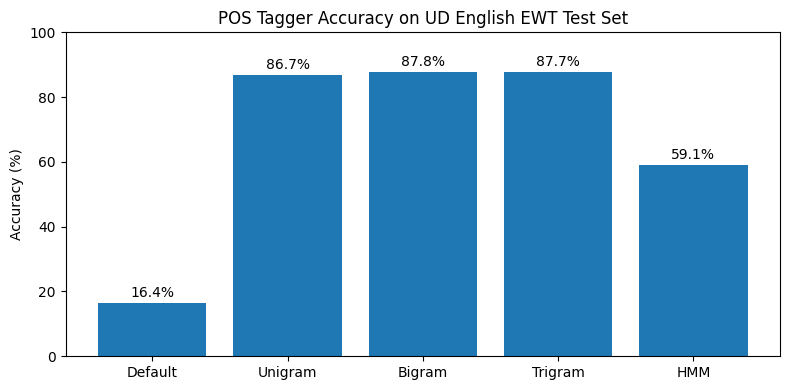

In [22]:
ud_train_all = ud_train_sents + ud_dev_sents

results_ud = run_pos_experiment(
    train_sents=ud_train_all,
    test_sents=ud_test_sents,
    dataset_name="UD English EWT",
    default_tag='NOUN'   # UD uses UPOS tags like NOUN, VERB, etc.
)


## 4. Cross‑dataset comparison

In [23]:
import pandas as pd

comparison_df = pd.DataFrame({
    "Tagger": results_brown["tagger_names"],
    "Brown_news(%)": [a * 100 for a in results_brown["accuracies"]],
    "UD_EWT(%)": [a * 100 for a in results_ud["accuracies"]],
})

comparison_df

,Tagger,Brown_news(%),UD_EWT(%)
0,Default,12.095958,16.430222
1,Unigram,82.672576,86.694030
2,Bigram,83.607110,87.825775
3,Trigram,83.438509,87.738105
4,HMM,28.960933,59.085837


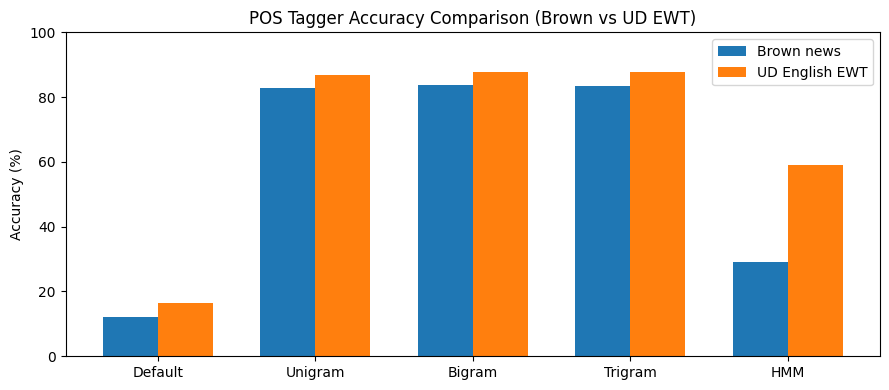

In [25]:
import numpy as np
import matplotlib.pyplot as plt

taggers = results_brown["tagger_names"]
x = np.arange(len(taggers))
width = 0.35

brown_vals = [a * 100 for a in results_brown["accuracies"]]
ud_vals    = [a * 100 for a in results_ud["accuracies"]]

plt.figure(figsize=(9, 4))
plt.bar(x - width/2, brown_vals, width, label='Brown news')
plt.bar(x + width/2, ud_vals, width, label='UD English EWT')

plt.xticks(x, taggers)
plt.ylabel("Accuracy (%)")
plt.ylim(0, 100)
plt.title("POS Tagger Accuracy Comparison (Brown vs UD EWT)")
plt.legend()
plt.tight_layout()
plt.show()

### Key observations

- The **Default tagger** (always predicting NN/NOUN) is a very weak baseline  
  – 12.1% on Brown and 16.4% on UD EWT.

- Moving to a **Unigram tagger** brings a huge jump in accuracy  
  – 82.7% (Brown) and 86.7% (UD EWT). The model simply memorizes the most
    common tag for each word.

- **Bigram and Trigram taggers** give small but consistent improvements
  over Unigram on both datasets:
  - Brown: 83.6% (Bigram) and 83.4% (Trigram)
  - UD EWT: 87.8% (Bigram) and 87.7% (Trigram)
  This shows that local context (previous tag(s)) helps disambiguate some
  words, but returns begin to saturate.

- In this experiment, the **HMM tagger** underperforms the n-gram taggers:
  - Brown: 29.0%
  - UD EWT: 59.1%
  This suggests that, with our simple configuration, the HMM is not using
  the data as effectively as the backed-off n-gram models. It may need more
  advanced smoothing or handling of unknown words to reach its full
  potential.

- All taggers achieve **higher accuracy on UD EWT** than on Brown. Likely
  reasons:
  - UD EWT uses a **smaller, universal POS tagset**, so the classification
    problem is slightly easier.
  - We train on both `train` and `dev` splits, giving more data than the
    Brown news subset.
